In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [3]:
X = np.linspace(0,10,40).reshape(-1,1)
 
# np.random.normal(0,5,40)is to generate random noise
# and add realistic variation to the output data.
# np.random.normal(mean,standard_deviation, number_of_values)
 
y = 2 + 0.5 * X[:,0] ** 2 + np.random.normal(0, 5, 40)
 
# Divide the data
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.30,random_state=42
)
 
degrees=[1,2,10]
 
# include_bias=False-is to tell PolynominalFeatures not to create
# an additional constant column containing only 1s
 
for degree in degrees:
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )
 
    model.fit(X_train, y_train)
 
    train_pred=model.predict(X_train)
    test_pred=model.predict(X_test)
 
    train_mse=mean_squared_error(y_train,train_pred)
    test_mse=mean_squared_error(y_test,test_pred)
 
    print(f"\nPolynomial Degree:{degree}")
    print(f"Training MSE:{train_mse:.2f}")
    print(f"Testing MSE:{test_mse:.2f}")


Polynomial Degree:1
Training MSE:24.12
Testing MSE:33.80

Polynomial Degree:2
Training MSE:17.94
Testing MSE:19.61

Polynomial Degree:10
Training MSE:17.29
Testing MSE:104.76


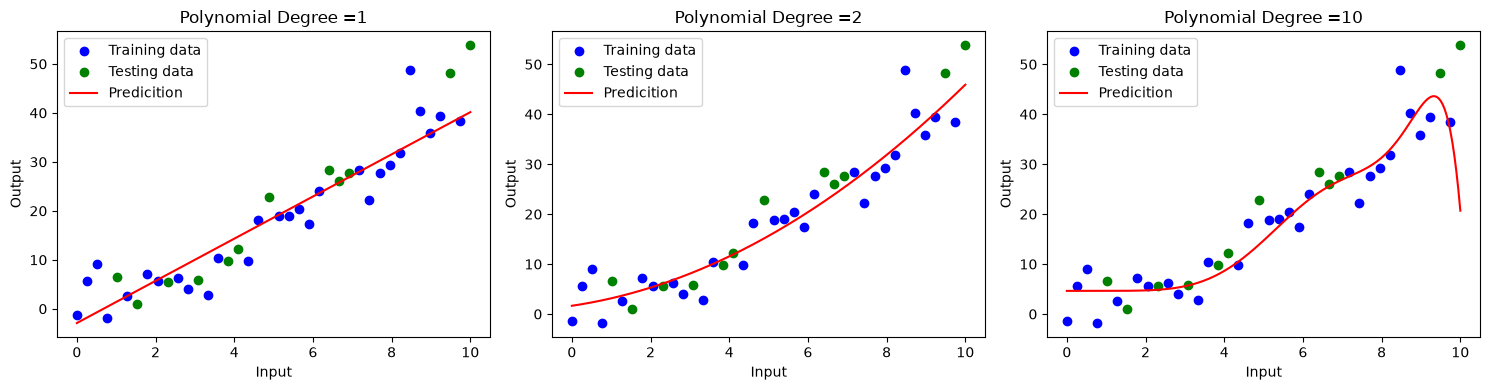

In [14]:
X_plot=np.linspace(0,10,200).reshape(-1,1)
plt.figure(figsize=(15,4))
for index, degree in enumerate(degrees):
    model=make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
 
    model.fit(X_train,y_train)
    y_plot=model.predict(X_plot)
 
    plt.subplot(1,3,index+1)
    plt.scatter(X_train,y_train,color="blue",label="Training data")
    plt.scatter(X_test,y_test,color="green",label="Testing data")
    plt.plot(X_plot,y_plot,color="red",label="Predicition")
 
    plt.title(f"Polynomial Degree ={degree}")
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.legend()
plt.tight_layout()
plt.show()

### Cross-Validation and model selection

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
 
for degree in range(1, 11):
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )
 
    scores=cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_mean_squared_error"
        # scikit-learn returns the negative value of the Mean Squared Error(MSE)
        # so that higher (less negative) values represent better model performance
    )
    mean_mse = -scores.mean()
    print(f"Degree{degree}: CV MSE={mean_mse:.2f}")

Degree1: CV MSE=56.96
Degree2: CV MSE=23.77
Degree3: CV MSE=86.03
Degree4: CV MSE=286.71
Degree5: CV MSE=56.08
Degree6: CV MSE=527.20
Degree7: CV MSE=986.37
Degree8: CV MSE=821.17
Degree9: CV MSE=53.57
Degree10: CV MSE=9640.93


In [15]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

X = pd.DataFrame({
    "constant_feature":[1,1,1,1,1],
    "almost_constant":[0,0,0,0,1],
    "useful_feature":[10,20,30,40,50]
})
selector = VarianceThreshold(threshold=0.0)
X_selected = selector.fit_transform(X)
selected_columns = X.columns[selector.get_support()]
print("Selected features:",list(selected_columns))


Selected features: ['almost_constant', 'useful_feature']


In [29]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

data = pd.DataFrame({
        "study_hours":[1,2,3,4,5,6],
        'attendance':[50,55,65,70,80,90],
        'previous_marks':[35,40,50,55,65,75],
        'final_marks':[38,45,52,60,70,82]
    })
    

                study_hours  attendance  previous_marks  final_marks
study_hours        1.000000    0.994100        0.994100     0.993478
attendance         0.994100    1.000000        1.000000     0.996852
previous_marks     0.994100    1.000000        1.000000     0.996852
final_marks        0.993478    0.996852        0.996852     1.000000


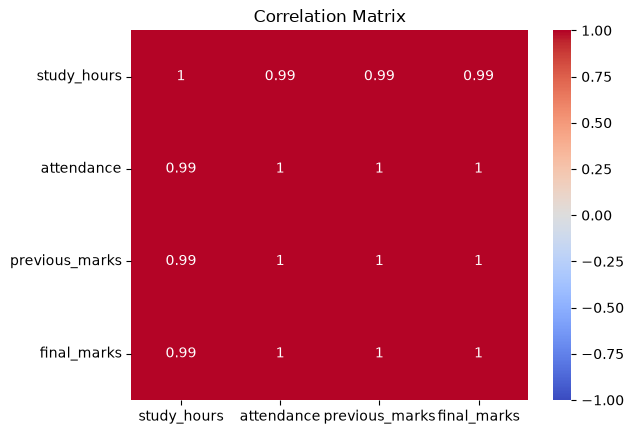

In [31]:
correlation_matrix = data.corr(numeric_only=True)

print(correlation_matrix)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title('Correlation Matrix')
plt.show()

###  CHI-SQUARETEST

In [19]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.preprocessing import MinMaxScaler

data =load_breast_cancer()
X = data.data
y = data.target

In [20]:
print("Number of features:",X.shape[1])

Number of features: 30


In [24]:
#chi-square requires non-negative features values
X_non_negative = MinMaxScaler().fit_transform(X)
selector = SelectKBest(score_func=chi2,k=5)
X_selected = selector.fit_transform(X_non_negative,y)
selected_features = data.feature_names[selector.get_support()]
print("Selected features:")
print(selected_features)

Selected features:
['mean concavity' 'mean concave points' 'worst perimeter' 'worst area'
 'worst concave points']


In [33]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest,chi2

In [34]:
iris = load_iris()
X,y = iris.data,iris.target

In [35]:
X_select = SelectKBest(chi2,k=3).fit_transform(X,y)
X_select.shape

(150, 3)

In [36]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest,f_classif

data = load_iris()
X = data.data
y = data.target

selector = SelectKBest(score_func=f_classif,k=2)
X_selected = selector.fit_transform(X,y)

import numpy as np
selected_features = np.array(data.feature_names)[selector.get_support()]
print("selected Features:",selected_features)

selected Features: ['petal length (cm)' 'petal width (cm)']


### ANOVA FOR REGRESSION F_Regression

In [37]:
from sklearn.feature_selection import SelectKBest,f_regression
selector = SelectKBest(score_func=f_regression,k=3)
X_selected = selector.fit_transform(X,y)